In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
data=pd.read_csv("car_fuel_efficiency_2026.csv")

In [3]:
data.columns.str.lower().str.replace(" ","_")

Index(['model_year', 'origin', 'fuel_type', 'drivetrain', 'num_doors',
       'engine_displacement', 'num_cylinders', 'horsepower', 'vehicle_weight',
       'acceleration', 'fuel_efficiency_mpg'],
      dtype='str')

In [4]:
cols=['engine_displacement',
'horsepower',
'vehicle_weight',
'model_year',
'fuel_efficiency_mpg']
df=data[cols]

In [5]:
df.describe()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
count,10000.000000,9123.000000,10000.000000,10000.000000,10000.000000
mean,2268.807000,254.446016,4286.754000,1999.549500,29.997700
std,183.447355,22.844613,266.212491,14.207925,2.930245
min,1590.000000,171.000000,3320.000000,1975.000000,19.800000
25%,2150.000000,239.000000,4110.000000,1987.000000,28.000000
50%,2270.000000,254.000000,4280.000000,2000.000000,30.000000
75%,2390.000000,270.000000,4470.000000,2012.000000,31.900000
max,3110.000000,334.000000,5460.000000,2024.000000,41.200000


In [6]:
#Q1
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   engine_displacement  10000 non-null  int64  
 1   horsepower           9123 non-null   float64
 2   vehicle_weight       10000 non-null  int64  
 3   model_year           10000 non-null  int64  
 4   fuel_efficiency_mpg  10000 non-null  float64
dtypes: float64(2), int64(3)
memory usage: 390.8 KB


In [7]:
df.dtypes

engine_displacement      int64
horsepower             float64
vehicle_weight           int64
model_year               int64
fuel_efficiency_mpg    float64
dtype: object

In [8]:
len(df)

10000

In [9]:
df.head(5)

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0


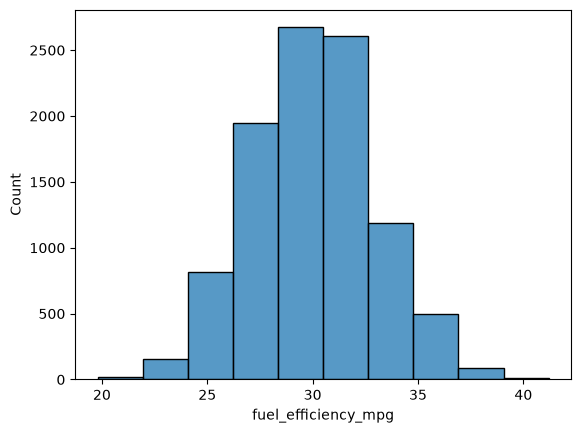

In [10]:
sns.histplot(df['fuel_efficiency_mpg'],bins=10)
plt.show()

In [11]:
#Q2
df['horsepower'].median()

np.float64(254.0)

In [23]:
#Q3
#1) Filling null values with zeroes
df0=df.copy()
df0['horsepower']=df0['horsepower'].fillna(0)

In [24]:
df0.isnull().sum()

engine_displacement    0
horsepower             0
vehicle_weight         0
model_year             0
fuel_efficiency_mpg    0
dtype: int64

In [29]:
n = len(df0)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df0.iloc[idx[:n_train]]
df_val = df0.iloc[idx[n_train:n_train + n_val]]
df_test = df0.iloc[idx[n_train + n_val:]]

In [30]:
def dot(xi, w):
    n = len(xi)
    
    res = 0.0
    
    for j in range(n):
        res = res + xi[j] * w[j]
    
    return res

In [31]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

In [32]:
X_train=df_train.copy()
Y_train=df_train['fuel_efficiency_mpg']
del X_train['fuel_efficiency_mpg']

In [33]:
w0, w = train_linear_regression(X_train, Y_train)
y_pred = w0 + X_train.dot(w)

In [37]:
w0

np.float64(-153.8849618823138)

In [35]:
w

array([-1.51505520e-03, -4.74024794e-06, -3.95418397e-03,  1.02146785e-01])